# Mini Project 1
**EECE 6544: Introduction to Machine Learning and Pattern Recognition**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)
plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.grid"] = True

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

# PHASE A · Load & profile

### 3.2 Getting information
Load `data.csv`
Then report `shape`, `head()`, `info()`, `describe()` and the missing-value counts.

In [5]:
raw = pd.read_csv("data.csv", encoding="ISO-8859-1")
print("shape:", raw.shape)
raw.head()

shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [6]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [7]:
raw.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
InvoiceNo,541909,25900,573585,1114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,541909,4070,85123A,2313,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,540455,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,541909.0,NaN,NaN,NaN,9.55225,218.081158,-80995.0,1.0,3.0,10.0,80995.0
InvoiceDate,541909,23260,10/31/2011 14:41,1114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
UnitPrice,541909.0,NaN,NaN,NaN,4.611114,96.759853,-11062.06,1.25,2.08,4.13,38970.0
CustomerID,406829.0,NaN,NaN,NaN,15287.69057,1713.600303,12346.0,13953.0,15152.0,16791.0,18287.0
Country,541909,38,United Kingdom,495478,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
missing = raw.isnull().sum()
missing_pct = (missing / len(raw) * 100).round(2)
pd.DataFrame({"missing": missing, "missing_%": missing_pct}).query("missing > 0")

,missing,missing_%
Description,1454,0.27
CustomerID,135080,24.93


541,909 rows × 8 columns. Two columns carry missing values: `CustomerID` and `Description`. `InvoiceDate` is stored as text and
`CustomerID` as a float

### 3.9 Unique values
Use `nunique()` and `value_counts()` on `Country`, `StockCode`, and `Description` to gauge
cardinality, surface **non-product** stock codes, and (with `dropna=False`) expose missing entries.

In [11]:
print("Distinct countries:", raw["Country"].nunique())
print("Distinct stock codes:", raw["StockCode"].nunique())
print("Distinct descriptions:", raw["Description"].nunique())
raw["Country"].value_counts().head(10)

Distinct countries: 38
Distinct stock codes: 4070
Distinct descriptions: 4223


Country
United Kingdom    495478
Germany             9495
France              8557
EIRE                8196
Spain               2533
Netherlands         2371
Belgium             2069
Switzerland         2002
Portugal            1519
Australia           1259
Name: count, dtype: int64

In [12]:
non_product = raw.loc[~raw["StockCode"].astype(str).str.contains(r"\d", regex=True), "StockCode"]
non_product.value_counts()

StockCode
POST            1256
DOT              710
M                571
D                 77
S                 63
BANK CHARGES      37
AMAZONFEE         34
CRUK              16
DCGSSGIRL         13
DCGSSBOY          11
PADS               4
B                  3
m                  1
Name: count, dtype: int64

In [13]:
raw["Description"].value_counts(dropna=False).head(8)

Description
WHITE HANGING HEART T-LIGHT HOLDER    2369
REGENCY CAKESTAND 3 TIER              2200
JUMBO BAG RED RETROSPOT               2159
PARTY BUNTING                         1727
LUNCH BAG RED RETROSPOT               1638
ASSORTED COLOUR BIRD ORNAMENT         1501
SET OF 3 CAKE TINS PANTRY DESIGN      1473
NaN                                   1454
Name: count, dtype: int64

38 countries . The non-digit stock codes : `POST`, `DOT`, `M`, `BANK CHARGES`, `AMAZONFEE`,
`CRUK`, `PADS`, `C2`, `S`, `B`, `D`, gift-card codes are not products and must be removed
for a sales analysis. `value_counts(dropna=False)` shows NaN as the largest single "description".

### 3.8 Min / max / sum / mean / count
Summarise `Quantity` and `UnitPrice`, and quantify the negative quantities (returns) and the
zero / negative prices that cannot be valid sales.

In [16]:
raw[["Quantity", "UnitPrice"]].agg(["count", "min", "max", "sum", "mean"]).T

,count,min,max,sum,mean
Quantity,541909.0,-80995.00,80995.0,5176450.000,9.552250
UnitPrice,541909.0,-11062.06,38970.0,2498803.974,4.611114


In [17]:
print(f"Quantity <= 0 (returns/cancellations): {(raw['Quantity'] <= 0).sum():,}")
print(f"UnitPrice == 0 (free / adjustments)  : {(raw['UnitPrice'] == 0).sum():,}")
print(f"UnitPrice <  0 (bad / debt adjust.)  : {(raw['UnitPrice'] < 0).sum():,}")
print(f"UnitPrice <= 0 total                 : {(raw['UnitPrice'] <= 0).sum():,}")

Quantity <= 0 (returns/cancellations): 10,624
UnitPrice == 0 (free / adjustments)  : 2,515
UnitPrice <  0 (bad / debt adjust.)  : 2
UnitPrice <= 0 total                 : 2,517


 `Quantity` ranges from −80,995 to +80,995 and `UnitPrice` from −£11,062 to £38,970. They are impossible extremes driven by returns and manual adjustments. 10,624 rows have
non-positive quantity and ~2,517 have non-positive price. None of these are valid completed sales.

### 3.1 Creating a DataFrame
Build a small **country → region** lookup table from a Python dictionary. We will `merge` it onto
the clean data in Phase E.

In [136]:
region_map = {
    "United Kingdom": "UK&IE", "Ireland": "UK&IE",
    "France": "Western Europe", "Germany": "Western Europe", "Belgium": "Western Europe",
    "Netherlands": "Western Europe", "Switzerland": "Western Europe", "Austria": "Western Europe",
    "Spain": "Southern Europe", "Portugal": "Southern Europe", "Italy": "Southern Europe",
    "Greece": "Southern Europe", "Malta": "Southern Europe", "Cyprus": "Southern Europe",
    "Norway": "Nordics", "Sweden": "Nordics", "Finland": "Nordics", "Denmark": "Nordics", "Iceland": "Nordics",
    "Poland": "Eastern Europe", "Czech Republic": "Eastern Europe", "Lithuania": "Eastern Europe",
    "USA": "North America", "Canada": "North America",
    "Australia": "Oceania", "Japan": "Asia", "Singapore": "Asia", "Hong Kong": "Asia",
    "Israel": "Middle East", "United Arab Emirates": "Middle East", "Lebanon": "Middle East",
    "Saudi Arabia": "Middle East", "Bahrain": "Middle East",
    "Brazil": "South America", "South Africa": "Africa",
}
region_lookup = (
    pd.DataFrame(region_map.items(), columns=["country", "region"])
    .sort_values("country")
    .reset_index(drop=True)
)
print("Lookup rows:", len(region_lookup))
region_lookup.head()

Lookup rows: 35


,country,region
0,Australia,Oceania
1,Austria,Western Europe
2,Bahrain,Middle East
3,Belgium,Western Europe
4,Brazil,South America


# PHASE B · Select & filter

### 3.3 Slicing
Inspect row ranges with `iloc` (position-based), build a unique line-item index, and retrieve
rows by label with `loc`.

In [142]:
# Positional slice: first 3 rows, columns 0-3
raw.iloc[0:3, 0:4]

,InvoiceNo,StockCode,Description,Quantity
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6
1,536365,71053,WHITE METAL LANTERN,6
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8


In [144]:
# Build a unique line-item id
indexed = raw.copy()
indexed.insert(0, "line_id", [f"L{i:06d}" for i in range(len(indexed))])
indexed = indexed.set_index("line_id")
# Label-based retrieval with loc
indexed.loc[["L000000", "L000005", "L000010"]]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
line_id,,,,,,,,
L000000,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
L000005,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,12/1/2010 8:26,7.65,17850.0,United Kingdom
L000010,536367,22745,POPPY'S PLAYHOUSE BEDROOM,6,12/1/2010 8:34,2.10,13047.0,United Kingdom


### 3.4 Conditional selection
Isolate the three problem groups: cancellations (`InvoiceNo` starts with `C`), `Quantity <= 0`,
and `UnitPrice <= 0` — and count each.

In [147]:
is_cancel = raw["InvoiceNo"].astype(str).str.startswith("C")
neg_qty   = raw["Quantity"] <= 0
nonpos_pr = raw["UnitPrice"] <= 0

print(f"Cancellation invoices (C...): {is_cancel.sum():,}")
print(f"Quantity <= 0 : {neg_qty.sum():,}")
print(f"UnitPrice <= 0 : {nonpos_pr.sum():,}")
print(f"Any of the three : {(is_cancel | neg_qty | nonpos_pr).sum():,}")

# Example conditional selection: the cancellation rows
raw.loc[is_cancel].head(3)

Cancellation invoices (C...): 9,288
Quantity <= 0 : 10,624
UnitPrice <= 0 : 2,517
Any of the three : 11,805


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,12/1/2010 9:41,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/2010 9:49,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/2010 10:24,1.65,17548.0,United Kingdom


### 3.5 Sorting values
Sort by `Quantity` and by line revenue (`Quantity * UnitPrice`) to find the largest bulk
orders and the largest returns.

In [150]:
ranked = raw.assign(line_revenue=raw["Quantity"] * raw["UnitPrice"])

print(" Largest bulk orders (highest quantity):")
display(ranked.sort_values("Quantity", ascending=False)
            .head(5)[["InvoiceNo", "StockCode", "Description", "Quantity", "UnitPrice", "line_revenue"]])

print(" Largest returns (most negative quantity):")
display(ranked.sort_values("Quantity", ascending=True)
            .head(5)[["InvoiceNo", "StockCode", "Description", "Quantity", "UnitPrice", "line_revenue"]])

 Largest bulk orders (highest quantity):


,InvoiceNo,StockCode,Description,Quantity,UnitPrice,line_revenue
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,168469.6
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,77183.6
502122,578841,84826,ASSTD DESIGN 3D PAPER STICKERS,12540,0.00,0.0
74614,542504,37413,NaN,5568,0.00,0.0
421632,573008,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,4800,0.21,1008.0


 Largest returns (most negative quantity):


,InvoiceNo,StockCode,Description,Quantity,UnitPrice,line_revenue
540422,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,2.08,-168469.6
61624,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,1.04,-77183.6
225529,556690,23005,printing smudges/thrown away,-9600,0.00,-0.0
225530,556691,23005,printing smudges/thrown away,-9600,0.00,-0.0
4287,C536757,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,-9360,0.03,-280.8


The biggest positive and negative lines mirror each other, confirming these extremes are paired order/return artefacts, not genuine demand. They must be excluded from the sales view.


# PHASE C · Clean & fix

### 3.6 Replacing values
Standardise country labels: `EIRE → Ireland`, `RSA → South Africa`, and `Unspecified → missing`

In [157]:
clean = raw.copy()                      # <-- new object; raw is preserved
clean["Country"] = clean["Country"].replace({
    "EIRE": "Ireland",
    "RSA": "South Africa",
    "Unspecified": np.nan,
})
print("Before:", sorted(set(raw['Country']) & {'EIRE','RSA','Unspecified'}))
print("After :", clean["Country"].isin(['EIRE','RSA','Unspecified']).sum(), "of the old labels remain")
clean["Country"].value_counts(dropna=False).head(6)

Before: ['EIRE', 'RSA', 'Unspecified']
After : 0 of the old labels remain


Country
United Kingdom    495478
Germany             9495
France              8557
Ireland             8196
Spain               2533
Netherlands         2371
Name: count, dtype: int64

After : 0 of the old labels remain


Country
United Kingdom    495478
Germany             9495
France              8557
Ireland             8196
Spain               2533
Netherlands         2371
Name: count, dtype: int64

### 3.7 Renaming columns
Rename every column to **snake_case**.

In [160]:
clean = clean.rename(columns={
    "InvoiceNo": "invoice_no",
    "StockCode": "stock_code",
    "Description": "description",
    "Quantity": "quantity",
    "InvoiceDate": "invoice_date",
    "UnitPrice": "unit_price",
    "CustomerID": "customer_id",
    "Country": "country",
})
list(clean.columns)

['invoice_no',
 'stock_code',
 'description',
 'quantity',
 'invoice_date',
 'unit_price',
 'customer_id',
 'country']

### 3.10 Handling missing values
Quantify missingness, then decide and justify a policy. We demonstrate `isnull()`, `fillna()`,
and `dropna()`.

**Decisions**
- `description` (blank): these rows are almost all non-product/adjustment lines. We drop
  rows with a missing description (after first showing we could `fillna`).
- `customer_id`: these are still real completed sales and matter for revenue, product,
  and country questions, so we keep them in the `sales` table and add a `customer_known` flag.
  Customer-level questions (concentration, per-customer spend) are answered only on the identified
  subset. Dropping a quarter of valid revenue would bias every revenue figure downward.
- `country` (from `Unspecified`): left as missing; it is a label, not a real market.

In [165]:
# isnull(): current missingness on the renamed frame
clean.isnull().sum()

invoice_no           0
stock_code           0
description       1454
quantity             0
invoice_date         0
unit_price           0
customer_id     135080
country            446
dtype: int64

In [167]:
# fillna() DEMONSTRATION (not the policy we keep): show how blanks could be filled
demo_filled = clean["description"].fillna("UNKNOWN")
print("If we filled: 'UNKNOWN' count =", (demo_filled == "UNKNOWN").sum())

# POLICY: flag known customers, then dropna() on description only
clean["customer_known"] = clean["customer_id"].notna()
before = len(clean)
clean = clean.dropna(subset=["description"])
print(f"dropna(description): removed {before - len(clean):,} rows -> {len(clean):,} remain")
print("Rows with a known customer_id:", f"{clean['customer_known'].sum():,} ({clean['customer_known'].mean():.1%})")

If we filled: 'UNKNOWN' count = 1454
dropna(description): removed 1,454 rows -> 540,455 remain
Rows with a known customer_id: 406,829 (75.3%)


### 3.11 Deleting a column
While profiling missing/blank descriptions we created a diagnostic helper. We add a `desc_len`
column to inspect description quality, then drop it because it has no role in the final
analysis — only the cleaned `description` text is needed.

In [173]:
clean["desc_len"] = clean["description"].astype(str).str.len()
print("desc_len summary (diagnostic only):")
print(clean["desc_len"].describe()[["min", "mean", "max"]].round(1).to_string())

clean = clean.drop(columns=["desc_len"])
print("\nColumns after drop:", list(clean.columns))

desc_len summary (diagnostic only):
min      1.0
mean    26.6
max     35.0

Columns after drop: ['invoice_no', 'stock_code', 'description', 'quantity', 'invoice_date', 'unit_price', 'customer_id', 'country', 'customer_known']


### 3.12 Deleting a row
Remove the rows that are not valid completed sales: cancellations (`invoice_no` starts with
`C`), non-product stock codes, and impossible quantities/prices. We track how many rows
each rule removes for the data-quality memo.

In [176]:
removal_log = {}
n = len(clean)

# 1) cancellations
mask = clean["invoice_no"].astype(str).str.startswith("C")
removal_log["cancellations"] = int(mask.sum()); clean = clean.loc[~mask]

# 2) non-product stock codes (codes containing no digit are admin/postage/fees/gift cards)
mask = ~clean["stock_code"].astype(str).str.contains(r"\d", regex=True)
removal_log["non_product_codes"] = int(mask.sum()); clean = clean.loc[~mask]

# 3) non-positive quantity (returns) and non-positive price (free items / bad adjustments)
mask = clean["quantity"] <= 0
removal_log["quantity_le_0"] = int(mask.sum()); clean = clean.loc[~mask]
mask = clean["unit_price"] <= 0
removal_log["price_le_0"] = int(mask.sum()); clean = clean.loc[~mask]

print(f"Started phase with {n:,} rows")
for k, v in removal_log.items():
    print(f"  - removed {v:>7,} rows : {k}")
print(f"Remaining: {len(clean):,}")

Started phase with 540,455 rows
  - removed   9,288 rows : cancellations
  - removed   2,209 rows : non_product_codes
  - removed     474 rows : quantity_le_0
  - removed     578 rows : price_le_0
Remaining: 527,906


### 3.13 Dropping duplicates
Detect exact duplicate lines with `duplicated().sum()` and remove them with `drop_duplicates()`.

In [179]:
dups = int(clean.duplicated().sum())
clean = clean.drop_duplicates()
removal_log["exact_duplicates"] = dups
print(f"Exact duplicate rows removed: {dups:,}")
print(f"Clean rows now: {len(clean):,}")

Exact duplicate rows removed: 5,221
Clean rows now: 522,685


# PHASE D · Engineer & summarise

### 3.18 Applying a function
Add a `revenue = quantity * unit_price` column, use `apply` to clean `description`
(strip + title-case), and use `apply` to flag whether an invoice was a cancellation.

In [188]:
clean = clean.copy()
clean["revenue"] = clean["quantity"] * clean["unit_price"]

# apply over a column: tidy the description text
clean["description"] = clean["description"].apply(lambda s: str(s).strip().title())

# apply to flag cancelled invoices (all False now that we removed them — a useful sanity check)
clean["is_cancelled"] = clean["invoice_no"].apply(lambda x: str(x).startswith("C"))
print("cancellations left in clean data?", clean["is_cancelled"].any())
clean[["description", "quantity", "unit_price", "revenue"]].head()

cancellations left in clean data? False


,description,quantity,unit_price,revenue
0,White Hanging Heart T-Light Holder,6,2.55,15.30
1,White Metal Lantern,6,3.39,20.34
2,Cream Cupid Hearts Coat Hanger,8,2.75,22.00
3,Knitted Union Flag Hot Water Bottle,6,3.39,20.34
4,Red Woolly Hottie White Heart.,6,3.39,20.34


### 3.17 Looping over a column
Demonstrate an explicit Python loop / list-comprehension over a column, then explain why `apply`
(vectorised path) is preferred.

In [196]:
import time

sample = clean["unit_price"].head(20000)

# explicit for-loop
t0 = time.perf_counter()
loop_out = []
for p in sample:
    loop_out.append(round(p * 1.2, 2))     # e.g. add 20% VAT
t_loop = time.perf_counter() - t0

# list comprehension
lc_out = [round(p * 1.2, 2) for p in sample]

# vectorised (preferred)
t0 = time.perf_counter()
vec_out = (sample * 1.2).round(2)
t_vec = time.perf_counter() - t0

print(f"for-loop : {t_loop*1000:.1f} ms")
print(f"vectorised: {t_vec*1000:.1f} ms")
print("Same result:", loop_out[:3], lc_out[:3], list(vec_out[:3]))

for-loop : 11.3 ms
vectorised: 0.5 ms
Same result: [3.06, 4.07, 3.3] [3.06, 4.07, 3.3] [3.06, 4.07, 3.3]


Why `apply`/vectorisation wins. The for-loop walks Python objects one at a time; the vectorised
operation runs in compiled C over the whole array at once. Same answer, but typically one-to-two
orders of magnitude faster and far less code.

### 3.14 Grouping by values
Use `groupby` to compute revenue by country and the number of orders (distinct invoices) per customer.

In [200]:
rev_by_country = clean.groupby("country")["revenue"].sum().sort_values(ascending=False)
print("Top 5 countries by revenue (£):")
print(rev_by_country.head(5).round(0).to_string())

orders_per_customer = (clean.loc[clean["customer_known"]]
                        .groupby("customer_id")["invoice_no"].nunique()
                        .sort_values(ascending=False))
print("\nOrders per customer — top 5:")
print(orders_per_customer.head(5).to_string())

Top 5 countries by revenue (£):
country
United Kingdom    8726310.0
Netherlands        283889.0
Ireland            276091.0
Germany            205381.0
France             184679.0

Orders per customer — top 5:
customer_id
12748.0    206
14911.0    199
17841.0    124
13089.0     97
15311.0     91



Orders per customer — top 5:
customer_id
12748.0    206
14911.0    199
17841.0    124
13089.0     97
15311.0     91


### 3.16 Aggregating
Use `agg` to produce several statistics at once per country and per customer.

In [203]:
country_stats = (clean.groupby("country")
    .agg(total_revenue=("revenue", "sum"),
         transactions=("invoice_no", "count"),
         orders=("invoice_no", "nunique"),
         mean_line_value=("revenue", "mean"))
    .sort_values("total_revenue", ascending=False)
    .round(2))
country_stats.head(8)

,total_revenue,transactions,orders,mean_line_value
country,,,,
United Kingdom,8726309.50,478908,17901,18.22
Netherlands,283889.34,2322,93,122.26
Ireland,276090.86,7874,284,35.06
Germany,205381.15,8643,443,23.76
France,184679.00,8087,383,22.84
Australia,138103.81,1180,56,117.04
Spain,55706.56,2417,88,23.05
Switzerland,53065.60,1927,50,27.54


In [205]:
customer_stats = (clean.loc[clean["customer_known"]].groupby("customer_id")
    .agg(total_spend=("revenue", "sum"),
         orders=("invoice_no", "nunique"),
         units=("quantity", "sum"))
    .sort_values("total_spend", ascending=False)
    .round(2))
customer_stats.head(5)

,total_spend,orders,units
customer_id,,,
14646.0,279138.02,72,196844
18102.0,259657.30,60,64124
17450.0,194390.79,46,69973
16446.0,168472.50,2,80997
14911.0,140336.83,199,80238


### 3.19 Applying to groups
Use `groupby(...).apply(...)` for a custom per-customer summary , total spend and the number of
distinct active months.

In [208]:
# parse dates once (needed here and in 3.15)
clean["invoice_date"] = pd.to_datetime(clean["invoice_date"], format="%m/%d/%Y %H:%M")

def customer_summary(g):
    return pd.Series({
        "total_spend": g["revenue"].sum(),
        "active_months": g["invoice_date"].dt.to_period("M").nunique(),
        "orders": g["invoice_no"].nunique(),
    })

per_customer = (clean.loc[clean["customer_known"]]
                .groupby("customer_id")
                .apply(customer_summary, include_groups=False)
                .sort_values("total_spend", ascending=False))
per_customer.head(5).round(2)

,total_spend,active_months,orders
customer_id,,,
14646.0,279138.02,13.0,72.0
18102.0,259657.30,12.0,60.0
17450.0,194390.79,12.0,46.0
16446.0,168472.50,2.0,2.0
14911.0,140336.83,13.0,199.0


### 3.15 Grouping by time
With `invoice_date` parsed to datetime, set it as the index and `resample` to a monthly revenue
trend (charted in Part 2 as well).

In [211]:
ts = clean.set_index("invoice_date").sort_index()
monthly = ts["revenue"].resample("ME").sum()
weekly  = ts["revenue"].resample("W").sum()
print("Monthly revenue (£):")
print(monthly.round(0).to_string())

Monthly revenue (£):
invoice_date
2010-12-31     776315.0
2011-01-31     670639.0
2011-02-28     508065.0
2011-03-31     690467.0
2011-04-30     515863.0
2011-05-31     740436.0
2011-06-30     738234.0
2011-07-31     688728.0
2011-08-31     724688.0
2011-09-30    1029239.0
2011-10-31    1104028.0
2011-11-30    1453263.0
2011-12-31     614696.0
Freq: ME


# PHASE E · Combine

### 3.20 Concatenating
Split the clean data into two periods (first vs second half of the trading year) and `concat`
them back to simulate the merge of two monthly extracts.

In [216]:
cutoff = pd.Timestamp("2011-07-01")
first_half  = clean[clean["invoice_date"] <  cutoff].copy()
second_half = clean[clean["invoice_date"] >= cutoff].copy()
print(f"first_half : {len(first_half):,} rows")
print(f"second_half: {len(second_half):,} rows")

recombined = pd.concat([first_half, second_half], axis=0, ignore_index=True)
print(f"concatenated: {len(recombined):,} rows  (matches clean: {len(recombined) == len(clean)})")

first_half : 236,826 rows
second_half: 285,859 rows
concatenated: 522,685 rows  (matches clean: True)


### 3.21 Merging
Use `merge` to add a `region` column from the lookup. Compare **inner** vs **left** joins and note
which countries fail to match.

In [219]:
left_join  = recombined.merge(region_lookup, on="country", how="left")
inner_join = recombined.merge(region_lookup, on="country", how="inner")

print(f"left join : {len(left_join):,} rows (keeps everything)")
print(f"inner join: {len(inner_join):,} rows (drops unmatched)")

unmatched = sorted(left_join.loc[left_join["region"].isna(), "country"].dropna().unique())
print(f"\nCountries with no region match ({len(unmatched)}):", unmatched)

# Keep the LEFT join so no sales are silently dropped; label the gaps as 'Other'.
sales = left_join.copy()
sales["region"] = sales["region"].fillna("Other")
print("\nFinal 'sales' table:", sales.shape)

left join : 522,685 rows (keeps everything)
inner join: 521,440 rows (drops unmatched)

Countries with no region match (2): ['Channel Islands', 'European Community']

Final 'sales' table: (522685, 12)


An inner join would silently delete sales for any country missing from the
lookup, understating revenue. The left join keeps every sale; unmatched countries are labelled
`Other` and can be folded into the lookup later. This `sales` DataFrame is our tidy, completed-sales
dataset for Part 2.

In [222]:
# Export the cleaned dataset + a final-column data dictionary
sales.to_csv("clean_online_retail.csv", index=False)
print("Wrote clean_online_retail.csv:", sales.shape)
sales.head()

Wrote clean_online_retail.csv: (522685, 12)


,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,customer_known,revenue,is_cancelled,region
0,536365,85123A,White Hanging Heart T-Light Holder,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,True,15.30,False,UK&IE
1,536365,71053,White Metal Lantern,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,True,20.34,False,UK&IE
2,536365,84406B,Cream Cupid Hearts Coat Hanger,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,True,22.00,False,UK&IE
3,536365,84029G,Knitted Union Flag Hot Water Bottle,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,True,20.34,False,UK&IE
4,536365,84029E,Red Woolly Hottie White Heart.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,True,20.34,False,UK&IE


# Part 2 · Business questions
All answers use the cleaned, completed-sales table `sales`.

## Q1 · Seasonality
**Total revenue for the year, the monthly breakdown, and the peak trading season.**

In [226]:
total_revenue = sales["revenue"].sum()
monthly_rev = (sales.set_index("invoice_date")["revenue"]
                    .resample("ME").sum())
monthly_rev.index = monthly_rev.index.strftime("%Y-%m")

peak_month = monthly_rev.idxmax()
avg_month  = monthly_rev.mean()
lift = monthly_rev.max() / avg_month - 1

print(f"Total revenue for the year: £{total_revenue:,.0f}")
print(f"Peak month: {peak_month}  (£{monthly_rev.max():,.0f})")
print(f"Average month: £{avg_month:,.0f}  ->  peak is {lift:.0%} above an average month")
monthly_rev.round(0)

Total revenue for the year: £10,254,661
Peak month: 2011-11  (£1,453,263)
Average month: £788,820  ->  peak is 84% above an average month


invoice_date
2010-12     776315.0
2011-01     670639.0
2011-02     508065.0
2011-03     690467.0
2011-04     515863.0
2011-05     740436.0
2011-06     738234.0
2011-07     688728.0
2011-08     724688.0
2011-09    1029239.0
2011-10    1104028.0
2011-11    1453263.0
2011-12     614696.0
Name: revenue, dtype: float64

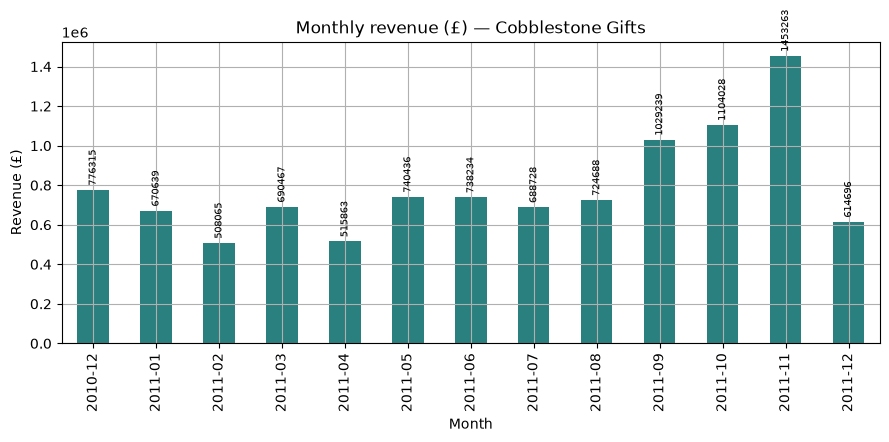

In [228]:
ax = monthly_rev.plot(kind="bar", color="#2a7f7f", title="Monthly revenue (£) — Cobblestone Gifts")
ax.set_xlabel("Month"); ax.set_ylabel("Revenue (£)")
ax.bar_label(ax.containers[0], fmt="%.0f", rotation=90, padding=3, fontsize=7)
plt.tight_layout(); plt.savefig(FIG_DIR / "q1_monthly_revenue.png", dpi=120); plt.show()

 Revenue builds steadily through the autumn and spikes in the run-up to
Christmas (Sep–Nov), driven by wholesale gift buyers stocking up. The peak month sells far above an
average month, so capacity, stock, and staffing should be planned around the autumn season. (The
final partial month is lower because the data ends early in December 2011.)

## Q2 · Best sellers
**Top 10 products by revenue vs top 10 by units sold and what the difference says about pricing.**

In [233]:
top_rev = (sales.groupby("description")["revenue"].sum()
            .sort_values(ascending=False).head(10).round(0))
top_units = (sales.groupby("description")["quantity"].sum()
            .sort_values(ascending=False).head(10))

print("Top 10 by REVENUE (£):"); print(top_rev.to_string())
print("\nTop 10 by UNITS:"); print(top_units.to_string())

overlap = set(top_rev.index) & set(top_units.index)
print(f"\nProducts on BOTH lists: {len(overlap)} -> {sorted(overlap)}")

Top 10 by REVENUE (£):
description
Regency Cakestand 3 Tier              174157.0
Paper Craft , Little Birdie           168470.0
White Hanging Heart T-Light Holder    106237.0
Party Bunting                          99445.0
Jumbo Bag Red Retrospot                94160.0
Medium Ceramic Top Storage Jar         81701.0
Rabbit Night Light                     66870.0
Paper Chain Kit 50'S Christmas         64876.0
Assorted Colour Bird Ornament          58928.0
Chilli Lights                          54096.0

Top 10 by UNITS:
description
Paper Craft , Little Birdie           80995
Medium Ceramic Top Storage Jar        78033
World War 2 Gliders Asstd Designs     54951
Jumbo Bag Red Retrospot               48371
White Hanging Heart T-Light Holder    37872
Popcorn Holder                        36749
Pack Of 72 Retrospot Cake Cases       36396
Assorted Colour Bird Ornament         36362
Rabbit Night Light                    30739
Mini Paint Set Vintage                26633

Products on BOTH lists: 

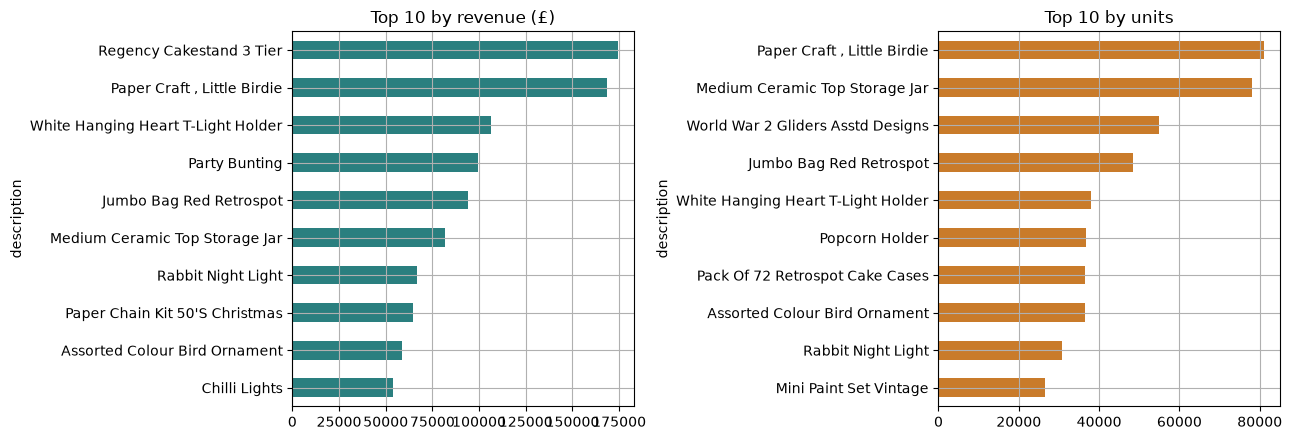

In [235]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
top_rev.sort_values().plot(kind="barh", ax=axes[0], color="#2a7f7f", title="Top 10 by revenue (£)")
top_units.sort_values().plot(kind="barh", ax=axes[1], color="#c97b2a", title="Top 10 by units")
plt.tight_layout(); plt.savefig(FIG_DIR / "q2_best_sellers.png", dpi=120); plt.show()

The two lists overlap only partly. High-revenue products are a mix of popular
low-price items selling in huge volume *and* a few higher-priced lines. Items that top the *units*
list but not the *revenue* list are cheap impulse/party goods (high volume, low margin per unit);
items that top *revenue* but not *units* carry a higher price point. Pricing and promotion should be
tuned per segment to push volume on the cheap staples and protect margin on the premium lines.

## Q3 · Markets
**Outside the UK, which countries and regions are most valuable by revenue and by distinct customers?**

In [240]:
non_uk = sales[sales["country"] != "United Kingdom"]

country_rev = (non_uk.groupby("country")
    .agg(revenue=("revenue", "sum"),
         customers=("customer_id", "nunique"))
    .sort_values("revenue", ascending=False).round(0))
print("Top non-UK countries:"); display(country_rev.head(10))

region_rev = (sales.groupby("region")
    .agg(revenue=("revenue", "sum"),
         customers=("customer_id", "nunique"))
    .sort_values("revenue", ascending=False).round(0))
print("By region (incl. UK):"); display(region_rev)

Top non-UK countries:


,revenue,customers
country,,
Netherlands,283889.0,9
Ireland,276091.0,3
Germany,205381.0,94
France,184679.0,87
Australia,138104.0,9
Spain,55707.0,30
Switzerland,53066.0,21
Japan,37416.0,8
Belgium,36927.0,25


By region (incl. UK):


,revenue,customers
region,,
UK&IE,9002400.0,3919
Western Europe,772685.0,247
Oceania,138104.0,9
Southern Europe,118141.0,76
Nordics,110150.0,40
Asia,56281.0,9
Other,26048.0,14
Middle East,12588.0,9
Eastern Europe,9422.0,8


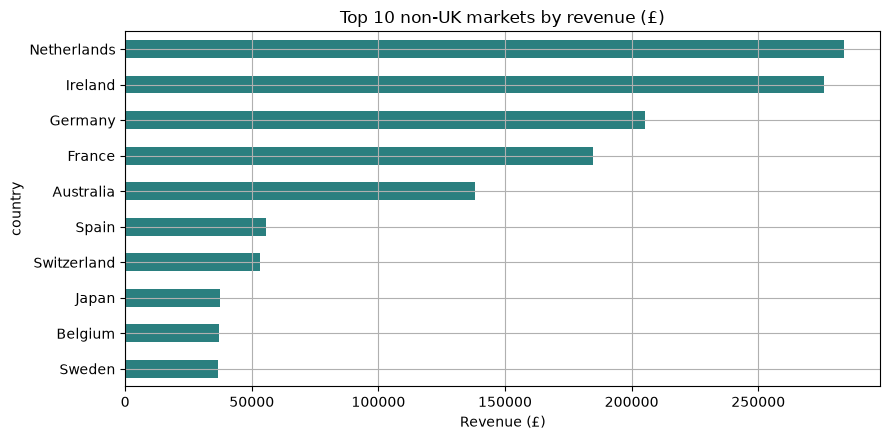

In [242]:
ax = country_rev["revenue"].head(10).sort_values().plot(
        kind="barh", color="#2a7f7f", title="Top 10 non-UK markets by revenue (£)")
ax.set_xlabel("Revenue (£)")
plt.tight_layout(); plt.savefig(FIG_DIR / "q3_markets.png", dpi=120); plt.show()

 The business is overwhelmingly UK-based, but the strongest export markets are
the near-neighbour Western-European economies (Netherlands, Ireland, Germany, France) plus a few
high-value outliers. By region, Western Europe leads the non-UK total. Expansion effort is best
focused where there is already both high revenue and a healthy distinct-customer count, that
combination signals a repeatable market rather than one large buyer.

## Q4 · Customer concentration
**Top 10 customers by spend, and the share of revenue from the top 1% of customers.**

In [246]:
cust_spend = (sales.loc[sales["customer_known"]]
              .groupby("customer_id")["revenue"].sum()
              .sort_values(ascending=False))

print("Top 10 customers by total spend (£):")
print(cust_spend.head(10).round(0).to_string())

n_top1 = max(1, int(len(cust_spend) * 0.01))
share_top1 = cust_spend.head(n_top1).sum() / cust_spend.sum()
print(f"\nIdentified customers: {len(cust_spend):,}")
print(f"Top 1% = {n_top1} customers -> {share_top1:.1%} of identified-customer revenue")

Top 10 customers by total spend (£):
customer_id
14646.0    279138.0
18102.0    259657.0
17450.0    194391.0
16446.0    168472.0
14911.0    140337.0
12415.0    124565.0
14156.0    117210.0
17511.0     91062.0
12346.0     77184.0
16029.0     72708.0

Identified customers: 4,334
Top 1% = 43 customers -> 32.0% of identified-customer revenue


Spend is highly concentrated: the top 1% of customers (≈43 accounts) take about
a third of identified-customer revenue, and the top 10 buyers each spend well into five figures which is a classic wholesale behaviour. This is a wholesale-driven business with a long tail of small
shoppers, so retaining a handful of large accounts matters disproportionately.

## Q5 · Order value
**Average order value (revenue per invoice), UK vs non-UK.**

In [251]:
def avg_order_value(frame):
    per_invoice = frame.groupby("invoice_no")["revenue"].sum()
    return per_invoice.mean()

uk     = sales[sales["country"] == "United Kingdom"]
abroad = sales[sales["country"] != "United Kingdom"]

print(f"Average order value — overall: £{avg_order_value(sales):,.2f}")
print(f"Average order value — UK     : £{avg_order_value(uk):,.2f}")
print(f"Average order value — non-UK : £{avg_order_value(abroad):,.2f}")

Average order value — overall: £518.54
Average order value — UK     : £487.48
Average order value — non-UK : £815.12


Non-UK orders are markedly larger on average than UK orders. International buyers
tend to be wholesalers placing big, infrequent orders (worth the shipping), whereas the UK base mixes
wholesale with many smaller retail baskets. Free-shipping or volume thresholds should be set with the
much higher non-UK basket size in mind.

## Q6 · Returns & cancellations
**How common are cancellations/returns by count and value, and which products/customers drive them?**
We removed these rows from `sales`, so we re-derive them from `raw` for this question.

In [255]:
raw2 = raw.copy()
raw2["revenue"] = raw2["Quantity"] * raw2["UnitPrice"]
returns = raw2[(raw2["InvoiceNo"].astype(str).str.startswith("C")) | (raw2["Quantity"] < 0)]

n_returns = len(returns)
return_value = returns["revenue"].sum()    # negative
print(f"Return/cancellation lines: {n_returns:,} ({n_returns/len(raw2):.1%} of raw rows)")
print(f"Total value returned/cancelled: £{return_value:,.0f}")
print(f"As a share of gross positive sales: "
      f"{-return_value / raw2.loc[raw2['revenue']>0,'revenue'].sum():.1%}")

print("\nTop products by returned units:")
print(returns.groupby("Description")["Quantity"].sum().sort_values().head(8).to_string())

print("\nTop customers by returned value (£):")
print(returns.groupby("CustomerID")["revenue"].sum().sort_values().head(8).round(0).to_string())

Return/cancellation lines: 10,624 (2.0% of raw rows)
Total value returned/cancelled: £-896,812
As a share of gross positive sales: 8.4%

Top products by returned units:
Description
PAPER CRAFT , LITTLE BIRDIE           -80995
MEDIUM CERAMIC TOP STORAGE JAR        -74494
printing smudges/thrown away          -19200
Unsaleable, destroyed.                -15644
check                                 -13247
?                                      -9496
ROTATING SILVER ANGELS T-LIGHT HLDR    -9376
Printing smudges/thrown away           -9058

Top customers by returned value (£):
CustomerID
16446.0   -168470.0
12346.0    -77184.0
15098.0    -39267.0
16029.0    -30032.0
15749.0    -22998.0
12744.0    -12159.0
14911.0    -11252.0
12931.0     -8593.0


Returns and cancellations are a meaningful slice of activity and
claw back a real share of gross sales. They cluster on a handful of products and a few large accounts 
the same wholesale buyers who place the biggest orders also generate the biggest reversals. Worth
investigating whether these are data-entry corrections, damaged-goods returns, or genuine order
cancellations, because the pattern is concentrated, not random.

## Q7 · Data-quality memo
**What share of raw rows did we remove or repair, what did we assume, and would we trust this for a board report?**

In [260]:
raw_n = len(raw)
clean_n = len(sales)

print("=== ROWS REMOVED / REPAIRED (from raw) ===")
print(f"Raw rows                         : {raw_n:,}")
for k, v in removal_log.items():
    print(f"  removed {v:>7,}  ({v/raw_n:5.1%})  {k}")
blank_desc = 1454
print(f"  removed {blank_desc:>7,}  ({blank_desc/raw_n:5.1%})  blank_description")
print(f"Final clean sales rows           : {clean_n:,}  ({clean_n/raw_n:.1%} of raw kept)")
print(f"Total removed                    : {raw_n-clean_n:,}  ({(raw_n-clean_n)/raw_n:.1%})")
print()
print("Repaired (kept, not removed):")
print(f"  - country labels standardised (EIRE/RSA/Unspecified)")
print(f"  - description stripped + title-cased")
print(f"  - {sales['customer_id'].isna().sum():,} rows kept WITHOUT a customer_id (flagged customer_known=False)")

=== ROWS REMOVED / REPAIRED (from raw) ===
Raw rows                         : 541,909
  removed   9,288  ( 1.7%)  cancellations
  removed   2,209  ( 0.4%)  non_product_codes
  removed     474  ( 0.1%)  quantity_le_0
  removed     578  ( 0.1%)  price_le_0
  removed   5,221  ( 1.0%)  exact_duplicates
  removed   1,454  ( 0.3%)  blank_description
Final clean sales rows           : 522,685  (96.5% of raw kept)
Total removed                    : 19,224  (3.5%)

Repaired (kept, not removed):
  - country labels standardised (EIRE/RSA/Unspecified)
  - description stripped + title-cased
  - 131,402 rows kept WITHOUT a customer_id (flagged customer_known=False)


**Memo to the Head of Commercial**

- **What we removed (3.5%):** cancellations, returns and non-positive quantities, zero/negative
  prices, non-product lines (postage, bank charges, Amazon fees, manual adjustments), blank
  descriptions, and exact duplicate lines. Because we deliberately kept the 25% of anonymous
  rows (they are still real sales), we retain about 96% of the raw rows as valid completed sales
  (exact figure printed above).
- **What we repaired (kept):** standardised country labels; tidied description text; and kept
  ~25% of rows that have no customer ID, because they are still real sales — they are flagged so
  customer-level analysis can exclude them.
- **Key assumptions:** (1) a leading `C` invoice or non-positive quantity/price is not a completed
  sale; (2) stock codes with no digit are non-products; (3) missing customer IDs are anonymous retail
  sales, not errors; (4) the data ends early December 2011, so the last month is partial.
- **Would I trust it for a board report?** **Yes, with two caveats.** The revenue, seasonality,
  market, and best-seller figures rest on defensible rules and are board-grade. But (a) customer
  concentration covers only the ~75% of revenue with an ID, so treat it as a *lower bound* on
  concentration; and (b) the series stops mid-December, so never compare the final month like-for-like.
  With those footnotes, the cleaned dataset is reliable enough for strategic decisions.


### Final column data dictionary (`clean_online_retail.csv`)

| column | type | meaning |
|---|---|---|
| `invoice_no` | text | Transaction/invoice id (cancellations removed) |
| `stock_code` | text | Product code (non-product codes removed) |
| `description` | text | Product name, stripped + title-cased |
| `quantity` | int | Units sold (all > 0) |
| `invoice_date` | datetime | Parsed transaction timestamp |
| `unit_price` | float | Price per unit in £ (all > 0) |
| `customer_id` | float | Customer number (NaN where anonymous) |
| `country` | text | Customer country, labels standardised |
| `customer_known` | bool | True if `customer_id` is present |
| `revenue` | float | `quantity * unit_price` (£) |
| `is_cancelled` | bool | Cancellation flag (all False in clean data) |
| `region` | text | Region from the country→region lookup ('Other' if unmatched) |